<div align="center">

# **Olist Revenue Intelligence — Late Delivery Modeling Dataset**

### Construction of an order-level predictive dataset for late delivery risk modeling

</div>

## 1. Notebook Objective

The purpose of this notebook is to construct a clean and defensible **order-level modeling dataset** for the prediction of late delivery risk.

This notebook does **not** focus on model training yet. Its objective is to:

- start from the corrected **V2 analytical dataset**
- define a valid **predictive scope**
- construct candidate features available at purchase time
- exclude variables that create **information leakage**
- validate the modeling grain and dataset quality
- export a final dataset ready for preprocessing and modeling

This predictive extension is part of the broader **Olist Revenue Intelligence Command Center** project.

The BI layer already showed that:
- operational friction is not evenly distributed
- geography is a major exposure lens
- revenue concentration must be interpreted together with execution fragility

The goal of this notebook is therefore to prepare the transition from:
- **descriptive diagnosis**
to
- **predictive anticipation**

## 2. Business Framing and Predictive Scope

### Business question

Can we identify, at purchase time, which delivered orders are at risk of being delivered late?

### Business rationale

The analytical and BI layers showed that Olist's strategic challenge is not revenue generation alone, but the uneven exposure of commercially important markets and portfolio segments to operational friction.

The predictive extension is therefore designed to support earlier operational prioritization, not to add machine learning artificially.

### Predictive scope

This notebook works under the following principles:

- the target variable is defined at the **order level**
- one row must correspond to **one order**
- the modeling population is restricted to **delivered orders with observable delivery outcome**
- only variables available at purchase time, or legitimately derivable from them, may be used as predictive features
- variables that depend on realized delivery or post-delivery feedback must be excluded

### Methodological continuity

This notebook builds on the corrected **V2 analytical logic**, after the earlier grain issue was identified and fixed.

That correction is important because late delivery must be modeled at the **order level**, not at the item level.

In [129]:
# ============================================================
# 0. Imports and setup
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 120)

RANDOM_STATE = 42

## 3. Load the Analytical Source Table

The modeling dataset is built from the corrected order-level analytical table produced in the previous notebook.

At this stage, the objective is not to rebuild the analytical layer from scratch, but to use it as the starting point for a predictive dataset construction process.

In [130]:
# ============================================================
# 1. Load source data
# ============================================================

DATA_PATH = Path("../data/processed/fact_orders.csv")

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nColumns:")
display(pd.DataFrame({"column": df.columns}))

Shape: (96478, 28)

Columns:


,column
0,order_id
1,customer_id
2,order_status
3,order_purchase_timestamp
4,order_approved_at
5,order_delivered_carrier_date
6,order_delivered_customer_date
7,order_estimated_delivery_date
8,customer_unique_id
9,customer_city


In [131]:
# Quick preview
display(df.head())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,order_revenue,n_items,n_sellers,n_categories,order_month,order_year,delivery_lead_time_days,estimated_vs_actual_days,is_late,review_score,n_reviews,review_creation_date,review_answer_timestamp,has_review,is_low_review,is_neutral_review,is_high_review
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,38.71,1,1,1,2017-10,2017,8.0,-8.0,0,4.0,1,2017-10-11 00:00:00,2017-10-12 03:43:48,1,0,0,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,BA,141.46,1,1,1,2018-07,2018,13.0,-6.0,0,4.0,1,2018-08-08 00:00:00,2018-08-08 18:37:50,1,0,0,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,179.12,1,1,1,2018-08,2018,9.0,-18.0,0,5.0,1,2018-08-18 00:00:00,2018-08-22 19:07:58,1,0,0,1
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,72.20,1,1,1,2017-11,2017,13.0,-13.0,0,5.0,1,2017-12-03 00:00:00,2017-12-05 19:21:58,1,0,0,1
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,28.62,1,1,1,2018-02,2018,2.0,-10.0,0,5.0,1,2018-02-17 00:00:00,2018-02-18 13:02:51,1,0,0,1


In [132]:
# Basic info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96478 entries, 0 to 96477
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       96478 non-null  str    
 1   customer_id                    96478 non-null  str    
 2   order_status                   96478 non-null  str    
 3   order_purchase_timestamp       96478 non-null  str    
 4   order_approved_at              96464 non-null  str    
 5   order_delivered_carrier_date   96476 non-null  str    
 6   order_delivered_customer_date  96470 non-null  str    
 7   order_estimated_delivery_date  96478 non-null  str    
 8   customer_unique_id             96478 non-null  str    
 9   customer_city                  96478 non-null  str    
 10  customer_state                 96478 non-null  str    
 11  order_revenue                  96478 non-null  float64
 12  n_items                        96478 non-null  int64  
 1

## 4. Validate the Modeling Grain

Before constructing any predictive dataset, the first requirement is to confirm that the source table is truly **order-level**.

This step is critical because the target variable `is_late` must be modeled at the same grain at which it is defined.

The earlier analytical iteration showed that delivery-related logic can be distorted when the grain is not treated correctly.  
This validation step therefore acts as a methodological safeguard.

In [133]:
# ============================================================
# 2. Validate modeling grain
# ============================================================

n_rows = len(df)
n_orders = df["order_id"].nunique()

print(f"Number of rows      : {n_rows:,}")
print(f"Number of unique orders : {n_orders:,}")
print(f"Rows == unique orders?  : {n_rows == n_orders}")

Number of rows      : 96,478
Number of unique orders : 96,478
Rows == unique orders?  : True


In [134]:
# Check duplicated order_ids
duplicated_orders = df[df["order_id"].duplicated(keep=False)].sort_values("order_id")

print("Number of duplicated order_ids:", duplicated_orders["order_id"].nunique())

if not duplicated_orders.empty:
    display(duplicated_orders.head(20))

Number of duplicated order_ids: 0


### Grain validation result

The source analytical table contains exactly one row per `order_id`, with no duplicated orders.

This confirms that the dataset is already aligned with the predictive target at the correct **order level**.

This validation is methodologically important because late delivery is defined at the order level, and the earlier analytical iteration showed that delivery-related logic can become misleading when the grain is not handled properly.

## 5. Define the Modeling Population

The late delivery target requires an **observed realized delivery date** and an **estimated delivery date**.

As a result, the modeling population is restricted to orders for which the delivery outcome is observable.

This means that:
- orders without a realized delivery date cannot be used
- orders without an estimated delivery date cannot be labeled
- the predictive scope is limited to **delivered orders with measurable delivery performance**

In [135]:
# ============================================================
# 3. Define modeling population
# ============================================================

required_target_columns = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

missing_required = [col for col in required_target_columns if col not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns for target construction: {missing_required}")

df_model_base = df.copy()

# Convert date columns
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "review_creation_date",
    "review_answer_timestamp"
]

existing_date_cols = [col for col in date_cols if col in df_model_base.columns]

for col in existing_date_cols:
    df_model_base[col] = pd.to_datetime(df_model_base[col], errors="coerce")

initial_rows = len(df_model_base)

df_model_base = df_model_base[
    df_model_base["order_delivered_customer_date"].notna()
    & df_model_base["order_estimated_delivery_date"].notna()
    & df_model_base["order_purchase_timestamp"].notna()
].copy()

final_rows = len(df_model_base)

print(f"Initial rows: {initial_rows:,}")
print(f"Rows after modeling population filter: {final_rows:,}")
print(f"Rows removed: {initial_rows - final_rows:,}")

Initial rows: 96,478
Rows after modeling population filter: 96,470
Rows removed: 8


In [136]:
# Optional check on order_status distribution if column exists
if "order_status" in df_model_base.columns:
    display(df_model_base["order_status"].value_counts(dropna=False).to_frame("count"))

,count
order_status,
delivered,96470


### Modeling population result

The modeling population remains highly representative of the original analytical table after filtering.

Only a very small number of observations were excluded, which means that the predictive scope does not materially distort the original order-level dataset.

All remaining observations correspond to delivered orders, which is consistent with the target construction logic used in this notebook.

## 6. Create the Target Variable

The target variable is:

- `is_late = 1` if the realized customer delivery date is later than the estimated delivery date
- `is_late = 0` otherwise

This target is aligned with the operational friction logic already explored in the analytical and BI layers.

At this stage, the goal is simply to validate that the target can be computed consistently and that its distribution is suitable for classification modeling.

In [137]:
# ============================================================
# 4. Create target variable
# ============================================================

# Keep original analytical target for validation
if "is_late" in df_model_base.columns:
    df_model_base["is_late_old"] = df_model_base["is_late"]

# Recompute target directly from timestamps
df_model_base["is_late_recomputed"] = (
    df_model_base["order_delivered_customer_date"] > df_model_base["order_estimated_delivery_date"]
).astype(int)

if "is_late_old" in df_model_base.columns:
    comparison = (df_model_base["is_late_old"] == df_model_base["is_late_recomputed"]).mean()
    print(f"Match rate between existing is_late and recomputed is_late: {comparison:.4%}")
else:
    print("Column 'is_late' not found. Using recomputed target only.")

# Final target used for DS
df_model_base["is_late"] = df_model_base["is_late_recomputed"]

Match rate between existing is_late and recomputed is_late: 98.6607%


In [138]:
# Inspect mismatches between inherited and recomputed target
if "is_late_old" in df_model_base.columns:
    mismatch_df = df_model_base[
        df_model_base["is_late_old"] != df_model_base["is_late_recomputed"]
    ].copy()

    print("Number of mismatches:", len(mismatch_df))
    print("Mismatch rate:", len(mismatch_df) / len(df_model_base))

    cols_to_display = [
        "order_id",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "estimated_vs_actual_days",
        "delivery_lead_time_days",
        "is_late_old",
        "is_late_recomputed"
    ]
    cols_to_display = [col for col in cols_to_display if col in mismatch_df.columns]

    display(mismatch_df[cols_to_display].head(20))

Number of mismatches: 1292
Mismatch rate: 0.013392764590027988


,order_id,order_delivered_customer_date,order_estimated_delivery_date,estimated_vs_actual_days,delivery_lead_time_days,is_late_old,is_late_recomputed
34,8563039e855156e48fccee4d611a3196,2018-03-20 00:59:25,2018-03-20,0.0,30.0,0,1
148,1d067305b599c1e0dceb3864056ea527,2018-03-09 21:52:36,2018-03-09,0.0,23.0,0,1
220,c82a457d646f77c8f151e12a3e517ed2,2018-08-15 15:02:09,2018-08-15,0.0,6.0,0,1
261,2c3a5e5f5bc3ae78ed5748461e62d47d,2018-02-06 15:49:01,2018-02-06,0.0,14.0,0,1
345,6cc4eb51469dec50a6130fe1cd07b7f9,2017-05-19 15:55:47,2017-05-19,0.0,11.0,0,1
372,5342acb7b183acec77f59e4d78f7c804,2018-04-24 16:10:44,2018-04-24,0.0,25.0,0,1
390,884b1394fc8888e6a877df86eb19e74c,2018-03-29 17:32:05,2018-03-29,0.0,9.0,0,1
634,2f4545bda1b1c794a9a35a3fbe4257ba,2018-06-05 15:38:50,2018-06-05,0.0,20.0,0,1
728,1a4cc55b483d875e3b8bbd64a1b31bba,2018-05-09 15:08:44,2018-05-09,0.0,27.0,0,1
737,ed24759a0ae96582e88fdca0c0997d22,2018-04-23 14:57:48,2018-04-23,0.0,30.0,0,1


In [139]:
target_distribution = (
    df_model_base["is_late"]
    .value_counts(dropna=False)
    .rename_axis("is_late")
    .reset_index(name="count")
)

target_distribution["share"] = target_distribution["count"] / target_distribution["count"].sum()

display(target_distribution)

,is_late,count,share
0,0,88644,0.918876
1,1,7826,0.081124


In [140]:
late_rate = df_model_base["is_late"].mean()

print(f"Global late delivery rate: {late_rate:.2%}")

Global late delivery rate: 8.11%


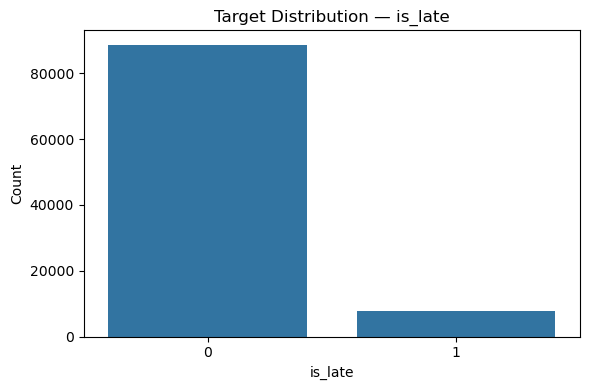

In [141]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_model_base, x="is_late")
plt.title("Target Distribution — is_late")
plt.xlabel("is_late")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Target validation result

The modeling population remains almost identical to the original analytical table after filtering, with only 8 observations removed due to missing delivery outcome or delivery estimate information. This confirms that the source table is already highly suitable for order-level predictive modeling.

After filtering, all remaining observations correspond to delivered orders, which is consistent with the predictive scope of this notebook: late delivery can only be evaluated when the realized delivery outcome is observable.

The target variable was recomputed directly from the realized and estimated delivery timestamps in order to validate the inherited analytical target.

A small mismatch was observed between the existing `is_late` field from the analytical table and the timestamp-based recomputed target. The mismatch rate is approximately 1.34%.

Inspection of the mismatched cases shows that they mainly correspond to orders delivered later on the same calendar day as the estimated delivery date. This indicates that the inherited target was likely derived from a day-based difference metric, which ignores intra-day delays.

For methodological rigor, the predictive layer uses the **recomputed timestamp-based target** as the final reference.

The final target distribution shows that late deliveries represent roughly 8% of delivered orders. The classification task is therefore moderately imbalanced, which means that accuracy alone will not be sufficient in the modeling phase. Precision, recall, F1-score and probability-based metrics will be emphasized in the next notebook.

## 7. Build Candidate Predictive Features

The candidate features are built under a strict rule:

> A feature can only be retained if it is available at purchase time, or legitimately derivable from information available at that moment.

This section focuses on a first defensible V1 feature set, built from:
- order structure
- purchase-time temporal patterns
- customer geography
- estimated delivery horizon

More advanced historical features may be added later, but only if they can be constructed without leakage.

### 7.1 Order Structure Features

Order structure variables are relevant because they may act as proxies for logistical complexity.

Examples include:
- order revenue
- number of items
- number of sellers
- number of categories

These variables are already aligned with the broader Revenue Intelligence logic, where structure matters more than raw aggregates alone.

In [142]:
# ============================================================
# 5. Build candidate features
# ============================================================

df_feat = df_model_base.copy()

# Ensure numeric columns are numeric
numeric_candidates = ["order_revenue", "n_items", "n_sellers", "n_categories"]

for col in numeric_candidates:
    if col in df_feat.columns:
        df_feat[col] = pd.to_numeric(df_feat[col], errors="coerce")

In [143]:
# Derived structural feature
if {"order_revenue", "n_items"}.issubset(df_feat.columns):
    df_feat["order_revenue_per_item"] = np.where(
        df_feat["n_items"] > 0,
        df_feat["order_revenue"] / df_feat["n_items"],
        np.nan
    )

### 7.2 Purchase-Time Temporal Features

Temporal features are derived from the purchase timestamp and are intended to capture:
- weekly patterns
- intraday effects
- possible seasonal or operational load effects

Only purchase-time information is used.

In [144]:
# Purchase-time temporal features
df_feat["purchase_month"] = df_feat["order_purchase_timestamp"].dt.month
df_feat["purchase_dayofweek"] = df_feat["order_purchase_timestamp"].dt.dayofweek
df_feat["purchase_hour"] = df_feat["order_purchase_timestamp"].dt.hour
df_feat["purchase_quarter"] = df_feat["order_purchase_timestamp"].dt.quarter
df_feat["is_weekend"] = df_feat["purchase_dayofweek"].isin([5, 6]).astype(int)

### 7.3 Estimated Delivery Horizon

The estimated delivery date itself should not be used directly as a raw timestamp.

However, the difference between:
- purchase timestamp
- estimated delivery date

can be converted into a valid purchase-time feature:

- `estimated_delivery_days`

This variable is acceptable because the delivery estimate is part of the order process and can reasonably be considered known once the order is placed.

In [145]:
# Estimated delivery horizon
df_feat["estimated_delivery_days"] = (
    (df_feat["order_estimated_delivery_date"] - df_feat["order_purchase_timestamp"])
    .dt.total_seconds() / (24 * 3600)
)

### 7.4 Customer Geography Features

The BI layer showed that geography is one of the main exposure lenses in the project.

Customer geography is therefore a strong candidate input for the predictive layer.

For the first version:
- `customer_state` is retained
- `customer_city` is excluded due to excessive granularity and cardinality

In [146]:
# Standardize customer_state as string category candidate
if "customer_state" in df_feat.columns:
    df_feat["customer_state"] = df_feat["customer_state"].astype("string").str.upper().str.strip()

In [147]:
# Quick preview of candidate feature columns
candidate_preview_cols = [
    col for col in [
        "order_id",
        "is_late",
        "order_revenue",
        "n_items",
        "n_sellers",
        "n_categories",
        "order_revenue_per_item",
        "purchase_month",
        "purchase_dayofweek",
        "purchase_hour",
        "purchase_quarter",
        "is_weekend",
        "estimated_delivery_days",
        "customer_state"
    ] if col in df_feat.columns
]

display(df_feat[candidate_preview_cols].head())

,order_id,is_late,order_revenue,n_items,n_sellers,n_categories,order_revenue_per_item,purchase_month,purchase_dayofweek,purchase_hour,purchase_quarter,is_weekend,estimated_delivery_days,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,0,38.71,1,1,1,38.71,10,0,10,4,0,15.544063,SP
1,53cdb2fc8bc7dce0b6741e2150273451,0,141.46,1,1,1,141.46,7,1,20,3,0,19.137766,BA
2,47770eb9100c2d0c44946d9cf07ec65d,0,179.12,1,1,1,179.12,8,2,8,3,0,26.639711,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,0,72.20,1,1,1,72.20,11,5,19,4,1,26.188819,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,0,28.62,1,1,1,28.62,2,1,21,1,0,12.112049,SP


## 8. Leakage Audit and Feature Exclusion Rules

A predictive dataset is only credible if variables that leak future information are explicitly removed.

This is especially important in this project because:
- the BI layer already includes realized delivery and review information
- those variables are useful analytically
- but they are invalid for prediction at purchase time

This section formalizes what is retained and what is excluded.

In [148]:
# ============================================================
# 6. Leakage audit
# ============================================================

leakage_audit = [
    ("order_id", "KEEP_ID_ONLY", "Identifier used for traceability and export, not as model input"),
    ("customer_id", "DROP", "Technical identifier, no predictive meaning as raw input"),
    ("customer_unique_id", "DROP_FROM_V1_MODEL", "Useful for future history engineering, but not as raw input"),
    ("customer_city", "DROP", "High cardinality for a first version"),
    ("customer_state", "KEEP", "Known before outcome and analytically relevant"),
    
    ("order_status", "DROP", "Not useful in delivered-only scope / may be constant or post-process dependent"),
    ("order_purchase_timestamp", "TRANSFORM_THEN_DROP", "Used to derive purchase-time calendar features"),
    ("order_approved_at", "DROP", "Ambiguous timing and not necessary for V1"),
    ("order_delivered_carrier_date", "DROP", "Post-purchase logistics event"),
    ("order_delivered_customer_date", "DROP", "Realized outcome date"),
    ("order_estimated_delivery_date", "TRANSFORM_THEN_DROP", "Used to derive estimated_delivery_days"),
    
    ("order_month", "DROP", "Redundant with reconstructed temporal features"),
    ("order_year", "DROP", "Low value in this first version"),
    
    ("order_revenue", "KEEP", "Order-level structural feature"),
    ("n_items", "KEEP", "Order complexity proxy"),
    ("n_sellers", "KEEP", "Order complexity proxy"),
    ("n_categories", "KEEP", "Order complexity proxy"),
    ("order_revenue_per_item", "KEEP", "Derived structural proxy"),
    
    ("delivery_lead_time_days", "DROP", "Derived from realized delivery"),
    ("estimated_vs_actual_days", "DROP", "Direct leakage from realized outcome"),
    ("is_late", "KEEP_TARGET", "Target variable"),
    
    ("review_score", "DROP", "Post-delivery feedback"),
    ("n_reviews", "DROP", "Post-delivery feedback"),
    ("review_creation_date", "DROP", "Post-delivery feedback timestamp"),
    ("review_answer_timestamp", "DROP", "Post-delivery feedback timestamp"),
    ("has_review", "DROP", "Post-delivery feedback"),
    ("is_low_review", "DROP", "Post-delivery feedback"),
    ("is_neutral_review", "DROP", "Post-delivery feedback"),
    ("is_high_review", "DROP", "Post-delivery feedback"),
]

audit_df = pd.DataFrame(leakage_audit, columns=["variable", "decision", "reason"])
display(audit_df)

,variable,decision,reason
0,order_id,KEEP_ID_ONLY,"Identifier used for traceability and export, n..."
1,customer_id,DROP,"Technical identifier, no predictive meaning as..."
2,customer_unique_id,DROP_FROM_V1_MODEL,"Useful for future history engineering, but not..."
3,customer_city,DROP,High cardinality for a first version
4,customer_state,KEEP,Known before outcome and analytically relevant
5,order_status,DROP,Not useful in delivered-only scope / may be co...
6,order_purchase_timestamp,TRANSFORM_THEN_DROP,Used to derive purchase-time calendar features
7,order_approved_at,DROP,Ambiguous timing and not necessary for V1
8,order_delivered_carrier_date,DROP,Post-purchase logistics event
9,order_delivered_customer_date,DROP,Realized outcome date


In [149]:
# Decisions summary
display(audit_df["decision"].value_counts().to_frame("count"))

,count
decision,
DROP,18
KEEP,6
TRANSFORM_THEN_DROP,2
KEEP_ID_ONLY,1
DROP_FROM_V1_MODEL,1
KEEP_TARGET,1


### Leakage audit comment

The leakage audit confirms a strict separation between:

#### Variables retained
- structural order features
- purchase-time temporal features
- customer geography
- estimated delivery horizon

#### Variables excluded
- realized delivery dates
- variables derived from actual delivery performance
- post-delivery review and feedback variables
- raw identifiers and overly granular geography

This distinction is necessary to ensure that the predictive task remains realistic.

## 9. Build the Final Feature Set

A first modeling version should remain disciplined.

The objective is not to maximize feature count, but to produce a clean and defensible V1 dataset with:
- low leakage risk
- manageable complexity
- meaningful connection to the BI findings

The final V1 feature set is intentionally limited.

In [150]:
# ============================================================
# 7. Define final V1 feature set
# ============================================================

id_columns = ["order_id"]
target_column = "is_late"

feature_columns = [
    "order_revenue",
    "n_items",
    "n_sellers",
    "n_categories",
    "customer_state",
    "estimated_delivery_days",
    "purchase_month",
    "purchase_dayofweek",
    "purchase_hour",
    "is_weekend",
    "order_revenue_per_item"
]

missing_feature_cols = [col for col in feature_columns if col not in df_feat.columns]
print("Missing feature columns:", missing_feature_cols)

Missing feature columns: []


In [151]:
# If one optional feature is missing, remove it cleanly
feature_columns = [col for col in feature_columns if col in df_feat.columns]

final_columns = id_columns + [target_column] + feature_columns

df_model_final = df_feat[final_columns].copy()

print("Final dataset shape:", df_model_final.shape)
display(df_model_final.head())

Final dataset shape: (96470, 13)


,order_id,is_late,order_revenue,n_items,n_sellers,n_categories,customer_state,estimated_delivery_days,purchase_month,purchase_dayofweek,purchase_hour,is_weekend,order_revenue_per_item
0,e481f51cbdc54678b7cc49136f2d6af7,0,38.71,1,1,1,SP,15.544063,10,0,10,0,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,0,141.46,1,1,1,BA,19.137766,7,1,20,0,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,0,179.12,1,1,1,GO,26.639711,8,2,8,0,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,0,72.20,1,1,1,RN,26.188819,11,5,19,1,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,0,28.62,1,1,1,SP,12.112049,2,1,21,0,28.62


### Final feature set result

The final V1 modeling dataset was successfully constructed with no missing candidate feature among the predefined feature set.

The resulting table contains:
- one row per delivered order
- a validated binary target (`is_late`)
- a compact set of structural, temporal and geographic predictors
- no direct post-outcome or post-delivery feedback leakage

This first version remains intentionally disciplined. It prioritizes methodological clarity and business relevance over feature proliferation.

## 10. Data Quality Checks

Before exporting the final modeling dataset, a few quality checks are required.

The objective is not to perform full exploratory analysis here, but to verify that the dataset is suitable for the next modeling notebook.

At this stage, the key points to review are:

- missing values
- categorical cardinality
- basic numerical distributions
- potential outliers or obvious anomalies
- consistency of the final modeling table

In [152]:
# ============================================================
# 8. Data quality checks
# ============================================================

missing_summary = (
    df_model_final.isna()
    .sum()
    .sort_values(ascending=False)
    .rename("n_missing")
    .to_frame()
)

missing_summary["missing_rate"] = missing_summary["n_missing"] / len(df_model_final)

display(missing_summary)

,n_missing,missing_rate
order_id,0,0.0
is_late,0,0.0
order_revenue,0,0.0
n_items,0,0.0
n_sellers,0,0.0
n_categories,0,0.0
customer_state,0,0.0
estimated_delivery_days,0,0.0
purchase_month,0,0.0
purchase_dayofweek,0,0.0


In [153]:
categorical_cols = df_model_final.select_dtypes(include=["object", "string", "category"]).columns.tolist()

cardinality_df = pd.DataFrame({
    "feature": categorical_cols,
    "n_unique": [df_model_final[col].nunique(dropna=False) for col in categorical_cols]
})

display(cardinality_df)

,feature,n_unique
0,order_id,96470
1,customer_state,27


In [154]:
display(df_model_final.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,96470,96470,e481f51cbdc54678b7cc49136f2d6af7,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_late,96470.0,NaN,NaN,NaN,0.081124,0.273026,0.0,0.0,0.0,0.0,1.0
order_revenue,96470.0,NaN,NaN,NaN,159.825799,218.802007,9.59,61.85,105.28,176.26,13664.08
n_items,96470.0,NaN,NaN,NaN,1.14221,0.538824,1.0,1.0,1.0,1.0,21.0
n_sellers,96470.0,NaN,NaN,NaN,1.013901,0.123542,1.0,1.0,1.0,1.0,5.0
n_categories,96470.0,NaN,NaN,NaN,0.993635,0.148036,0.0,1.0,1.0,1.0,3.0
customer_state,96470,27,SP,40494,NaN,NaN,NaN,NaN,NaN,NaN,NaN
estimated_delivery_days,96470.0,NaN,NaN,NaN,23.736343,8.761052,2.008009,18.329905,23.23088,28.407795,155.135463
purchase_month,96470.0,NaN,NaN,NaN,6.031046,3.228479,1.0,3.0,6.0,8.0,12.0
purchase_dayofweek,96470.0,NaN,NaN,NaN,2.756494,1.967041,0.0,1.0,3.0,4.0,6.0


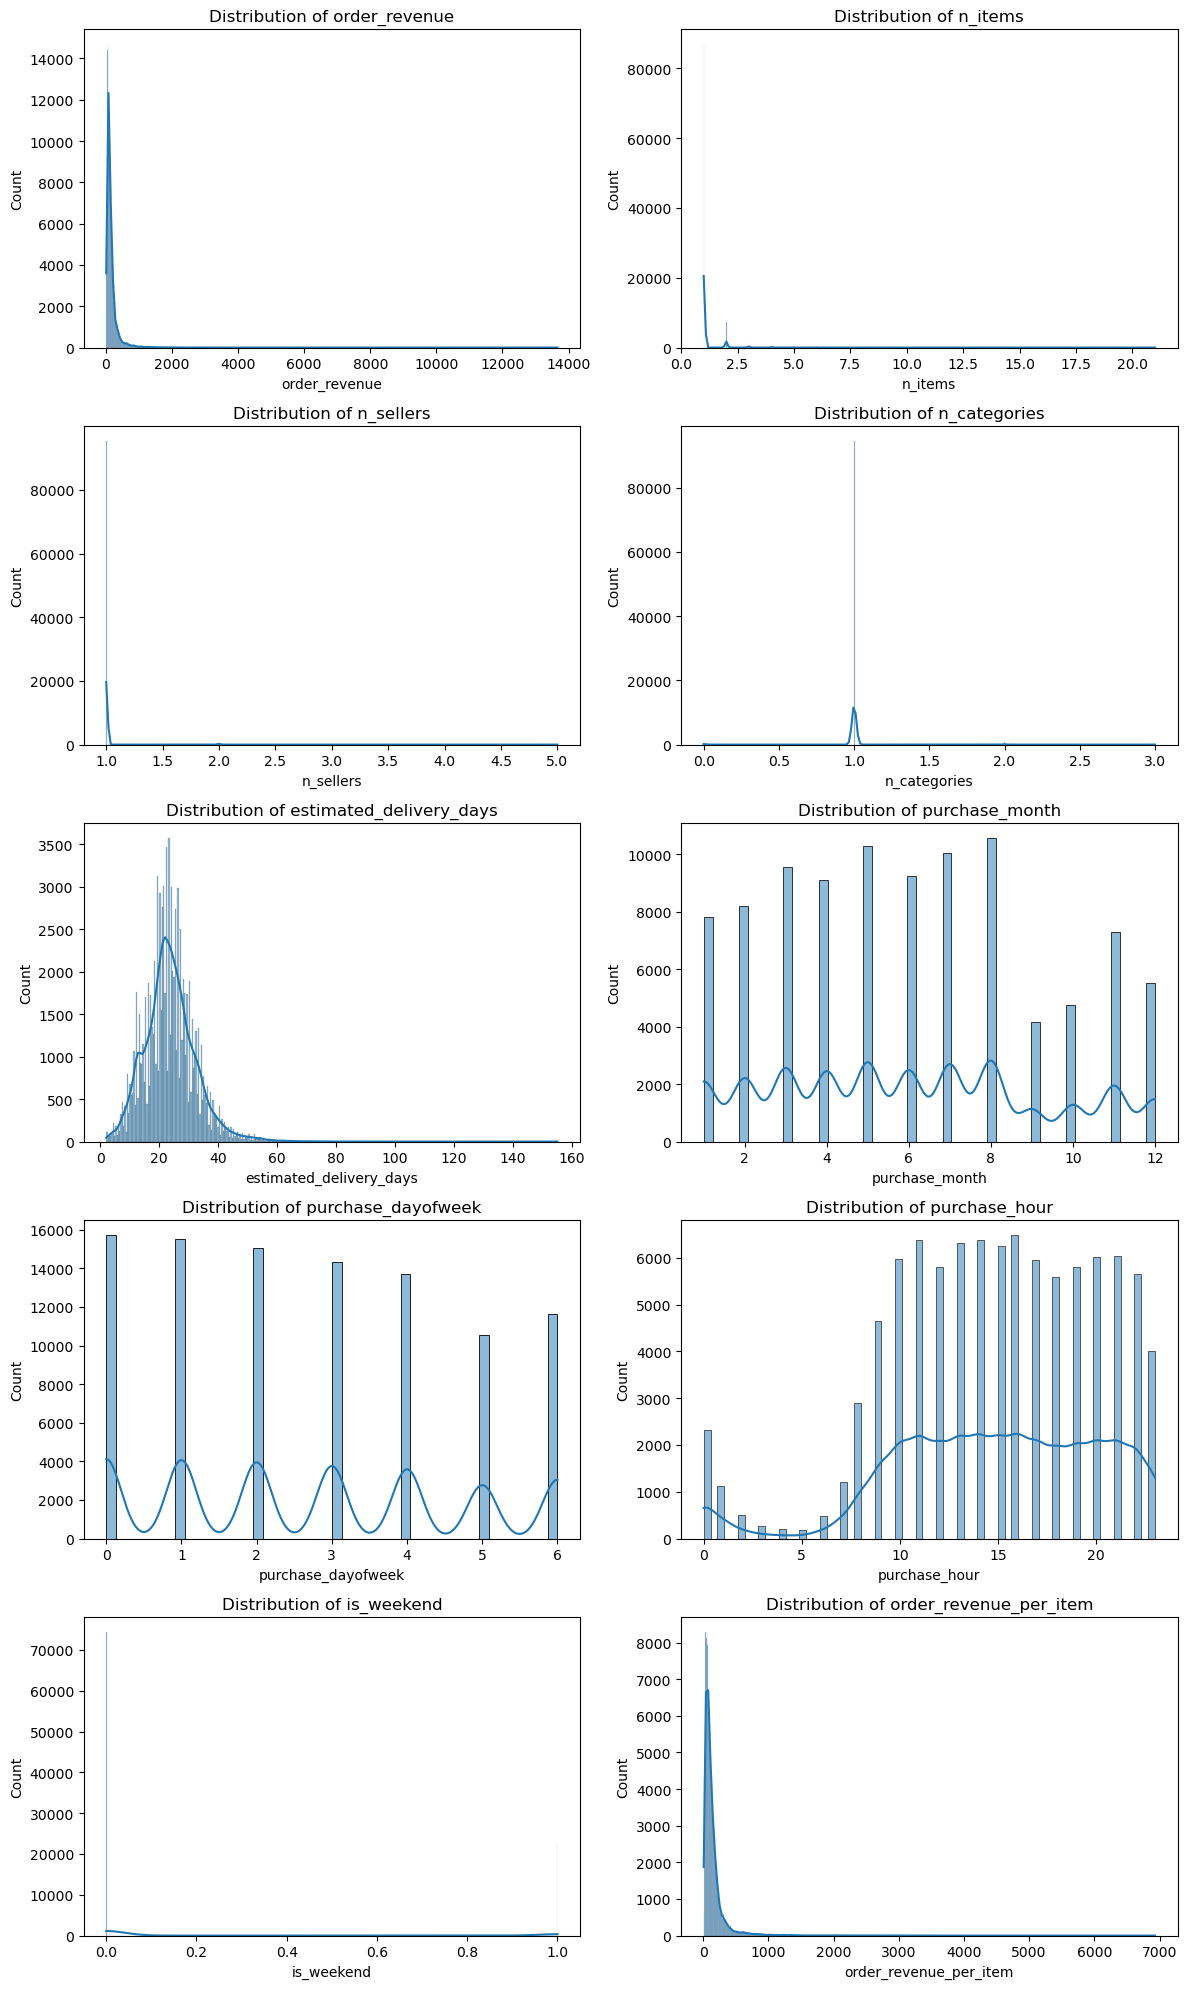

In [155]:
numeric_cols = df_model_final.select_dtypes(include=["number"]).columns.tolist()
numeric_cols_for_plot = [col for col in numeric_cols if col != "is_late"]

n_cols = 2
n_rows = int(np.ceil(len(numeric_cols_for_plot) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, numeric_cols_for_plot):
    sns.histplot(df_model_final[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")

for ax in axes[len(numeric_cols_for_plot):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

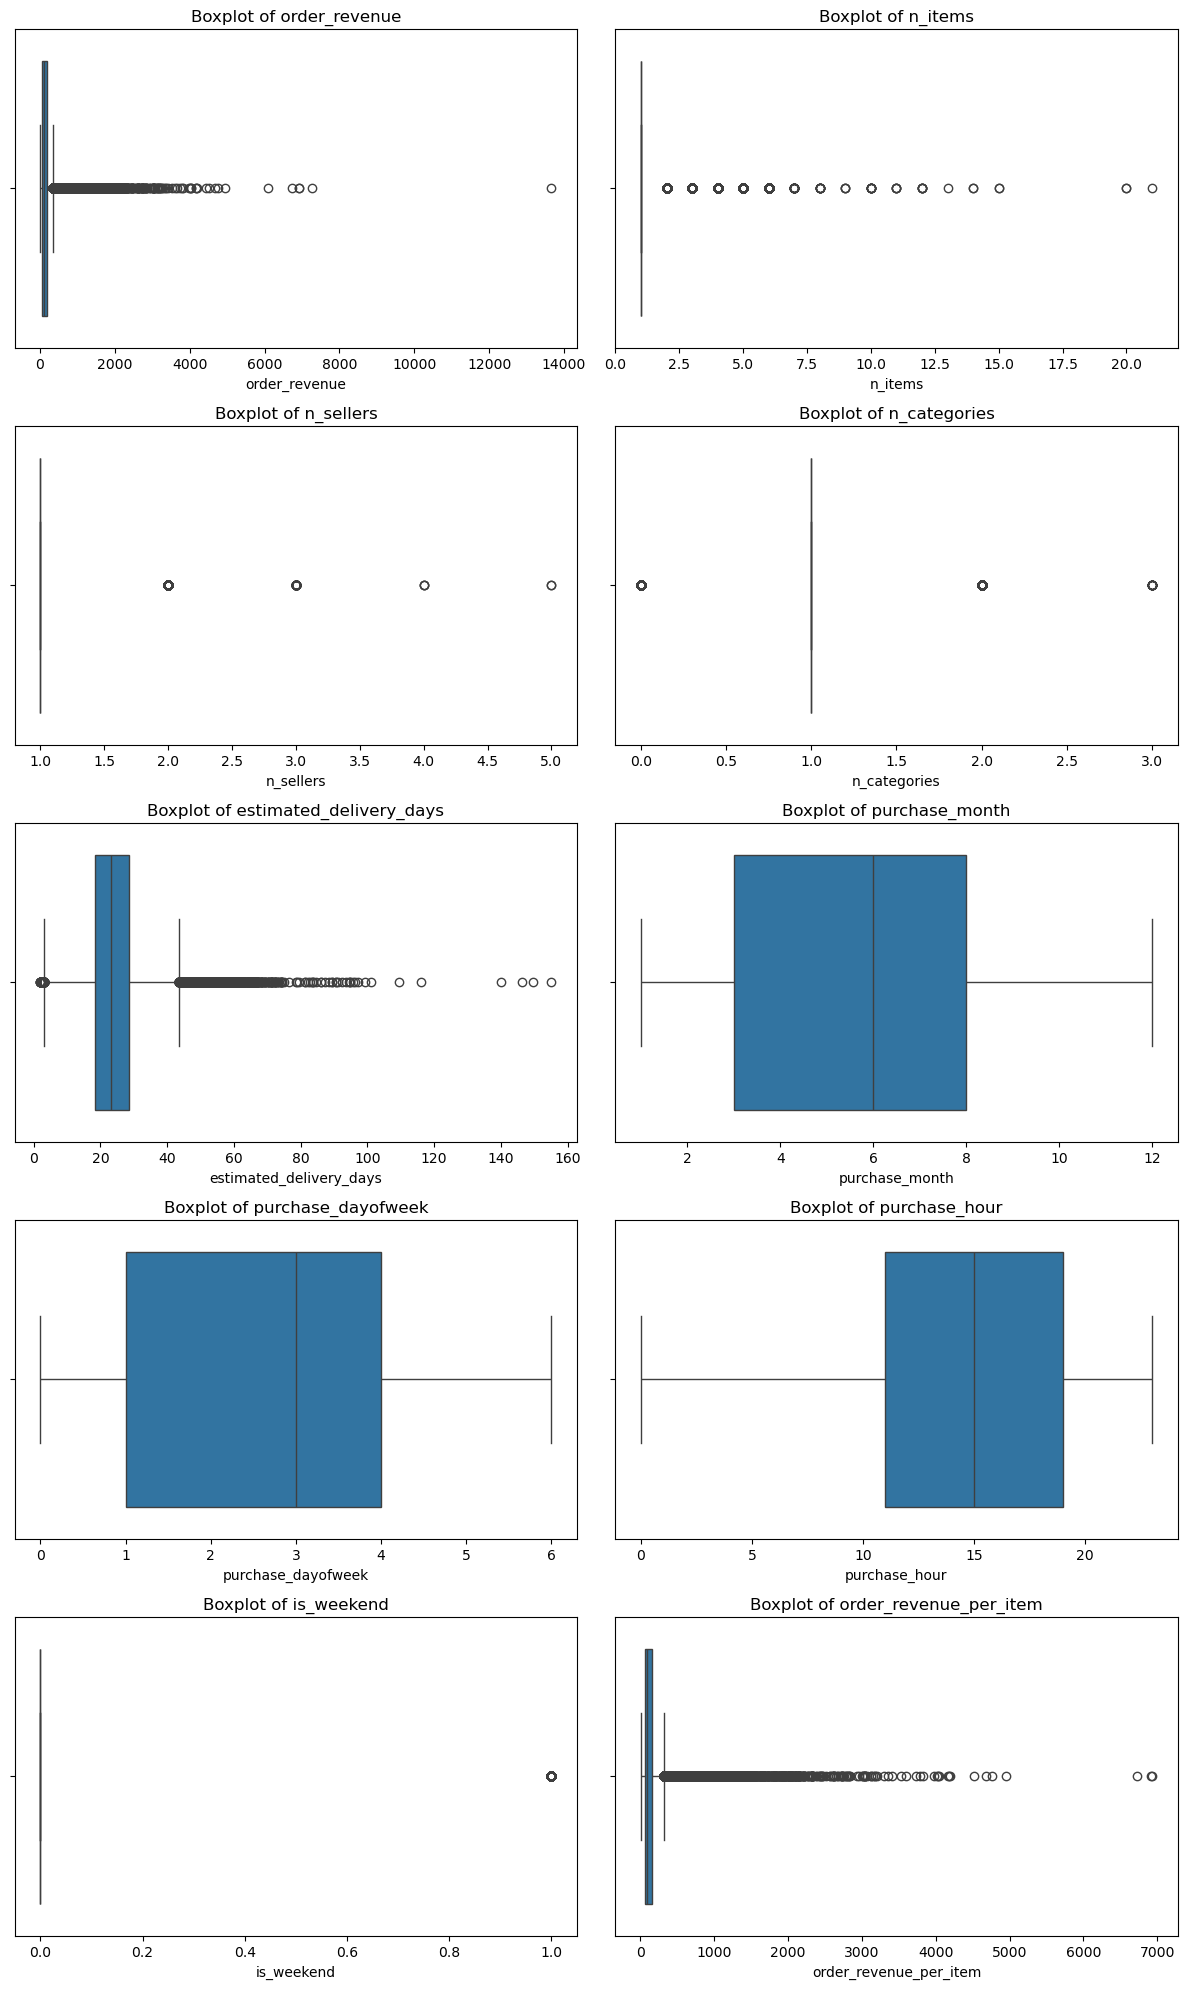

In [156]:
n_cols = 2
n_rows = int(np.ceil(len(numeric_cols_for_plot) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, numeric_cols_for_plot):
    sns.boxplot(x=df_model_final[col], ax=ax)
    ax.set_title(f"Boxplot of {col}")

for ax in axes[len(numeric_cols_for_plot):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

### Data quality check result

The final modeling dataset shows no missing values across the retained features, which confirms that the V1 feature set is immediately usable for classification modeling without additional imputation at this stage.

Categorical cardinality remains fully manageable:
- `customer_state` contains 27 modalities, which is suitable for standard encoding in the next notebook.

The numerical distributions reveal the expected profile of transactional e-commerce data:
- revenue-related variables are strongly right-skewed
- order structure variables (`n_items`, `n_sellers`, `n_categories`) are concentrated around low values
- estimated delivery horizon is centered on plausible operational lead times, with a limited right tail

Several outliers are visible, especially for revenue-related features and estimated delivery horizon, but they appear to reflect real transactional heterogeneity rather than obvious data quality failure.

At this stage, no variable needs to be removed on data quality grounds. Any treatment related to scaling, encoding or robustness to skewness will be handled in the next notebook.

## 11. Final Cleanup Before Export

The target validation step introduced temporary audit columns used to compare the inherited analytical target with the recomputed timestamp-based target.

These columns are useful for methodological validation, but they should not remain in the final exported modeling dataset.

They are therefore removed from the feature-enriched table before export.

In [157]:
# ============================================================
# 9. Final cleanup before export
# ============================================================

cols_to_drop_after_target_check = [
    col for col in ["is_late_old", "is_late_recomputed"] if col in df_feat.columns
]

if cols_to_drop_after_target_check:
    df_feat.drop(columns=cols_to_drop_after_target_check, inplace=True)

print("Dropped temporary target validation columns:", cols_to_drop_after_target_check)

Dropped temporary target validation columns: ['is_late_old', 'is_late_recomputed']


In [158]:
# Rebuild final modeling table after cleanup to ensure consistency
final_columns = id_columns + [target_column] + feature_columns
df_model_final = df_feat[final_columns].copy()

print("Final dataset shape after cleanup:", df_model_final.shape)
display(df_model_final.head())

Final dataset shape after cleanup: (96470, 13)


,order_id,is_late,order_revenue,n_items,n_sellers,n_categories,customer_state,estimated_delivery_days,purchase_month,purchase_dayofweek,purchase_hour,is_weekend,order_revenue_per_item
0,e481f51cbdc54678b7cc49136f2d6af7,0,38.71,1,1,1,SP,15.544063,10,0,10,0,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,0,141.46,1,1,1,BA,19.137766,7,1,20,0,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,0,179.12,1,1,1,GO,26.639711,8,2,8,0,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,0,72.20,1,1,1,RN,26.188819,11,5,19,1,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,0,28.62,1,1,1,SP,12.112049,2,1,21,0,28.62


## 12. Export the Final Modeling Dataset

The final output of this notebook is a clean order-level dataset ready for preprocessing and classification modeling.

Two exports are produced:

- the final modeling dataset
- the leakage audit table

This export will serve as the direct input for the next notebook, which will focus on preprocessing, model training and evaluation.

In [159]:
# ============================================================
# 10. Export outputs
# ============================================================

OUTPUT_DATA_PATH = Path("../data/processed/late_delivery_modeling_dataset.csv")
OUTPUT_AUDIT_PATH = Path("../data/exports/late_delivery_feature_audit.csv")

OUTPUT_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
OUTPUT_AUDIT_PATH.parent.mkdir(parents=True, exist_ok=True)

df_model_final.to_csv(OUTPUT_DATA_PATH, index=False)
audit_df.to_csv(OUTPUT_AUDIT_PATH, index=False)

print(f"Modeling dataset exported to: {OUTPUT_DATA_PATH}")
print(f"Leakage audit exported to   : {OUTPUT_AUDIT_PATH}")

Modeling dataset exported to: ..\data\processed\late_delivery_modeling_dataset.csv
Leakage audit exported to   : ..\data\exports\late_delivery_feature_audit.csv


In [160]:
print("Exported dataset shape:", df_model_final.shape)

print("\nFinal columns:")
display(pd.DataFrame({"column": df_model_final.columns}))

Exported dataset shape: (96470, 13)

Final columns:


,column
0,order_id
1,is_late
2,order_revenue
3,n_items
4,n_sellers
5,n_categories
6,customer_state
7,estimated_delivery_days
8,purchase_month
9,purchase_dayofweek
